In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!ls /content/drive

MyDrive


In [ ]:
!ls "/content/drive/My Drive"

'Colab Notebooks'  'deep learning project '   merged_dataset
 dataset_split	    final_dataset


In [ ]:
!ls "/content/drive/MyDrive/deep learning project "

'dataset 1'  'dataset 1.zip'  'dataset 2'  'dataset 2.zip'


In [ ]:
import os

# 2️⃣ Define the folder to search (change this to your folder)
search_folder = "/content/drive/MyDrive/"

# 3️⃣ Walk through folder and list all ZIP files
zip_files = []
for root, dirs, files in os.walk(search_folder):
    for file in files:
        if file.lower().endswith(".zip"):
            zip_path = os.path.join(root, file)
            zip_files.append(zip_path)

# 4️⃣ Print all found ZIP files
if zip_files:
    print("Found ZIP files:")
    for z in zip_files:
        print(z)
else:
    print("No ZIP files found in", search_folder)


Found ZIP files:
/content/drive/MyDrive/deep learning project /dataset 2.zip
/content/drive/MyDrive/deep learning project /dataset 1.zip


In [ ]:
merged_dir = "/content/drive/MyDrive/merged_dataset"
os.makedirs(merged_dir, exist_ok=True)

print(os.path.exists(merged_dir))

True


In [ ]:
import os
import zipfile

# 1️⃣ Define the main folder to search for ZIP files
# Change this path to the folder where your ZIP files are stored
search_folder = "/content/drive/MyDrive/"

# 2️⃣ Walk through the folder and find all ZIP files
zip_files = []  # List to store full paths of ZIP files
for root, dirs, files in os.walk(search_folder):
    for file in files:
        if file.lower().endswith(".zip"):  # Check if the file has .zip extension
            zip_path = os.path.join(root, file)  # Get the full path to the ZIP file
            zip_files.append(zip_path)  # Add to the list

# 3️⃣ Print all found ZIP files
if zip_files:
    print("Found ZIP files:")
    for z in zip_files:
        print(z)  # Print full path of each ZIP file
else:
    print("No ZIP files found in", search_folder)

# 4️⃣ Extract each ZIP file
for z in zip_files:
    # Create a folder to extract the ZIP contents
    # The folder has the same name as the ZIP file but without the .zip extension
    extract_dir = os.path.join(os.path.dirname(z), os.path.splitext(os.path.basename(z))[0])
    os.makedirs(extract_dir, exist_ok=True)  # Create folder if it doesn't exist

    # Open the ZIP file and extract all its contents into the folder
    with zipfile.ZipFile(z, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)

    # Print a message confirming extraction
    print(f"Extracted {z} to {extract_dir}")

Found ZIP files:
/content/drive/MyDrive/deep learning project /dataset 2.zip
/content/drive/MyDrive/deep learning project /dataset 1.zip
Extracted /content/drive/MyDrive/deep learning project /dataset 2.zip to /content/drive/MyDrive/deep learning project /dataset 2
Extracted /content/drive/MyDrive/deep learning project /dataset 1.zip to /content/drive/MyDrive/deep learning project /dataset 1


In [ ]:
import os
import shutil


dataset1 = "/content/drive/MyDrive/deep learning project /dataset 1/dataset 1"
dataset2 = "/content/drive/MyDrive/deep learning project /dataset 2/dataset 2"

output_dir = "/content/drive/MyDrive/merged_dataset"
os.makedirs(output_dir, exist_ok=True)

classes = os.listdir(dataset1)

for cls in classes:
    cls_out = os.path.join(output_dir, cls)
    os.makedirs(cls_out, exist_ok=True)

    # dataset 1
    cls_path1 = os.path.join(dataset1, cls)
    for img in os.listdir(cls_path1):
        src = os.path.join(cls_path1, img)
        dst = os.path.join(cls_out, img)
        shutil.copy(src, dst)

    # dataset 2
    cls_path2 = os.path.join(dataset2, cls)
    for img in os.listdir(cls_path2):
        src = os.path.join(cls_path2, img)
        dst = os.path.join(cls_out, f"sec2_{img}")
        shutil.copy(src, dst)

print("✅ Dataset merged successfully")

✅ Dataset merged successfully


In [ ]:
from collections import Counter

class_counts = {}

for cls in classes:
    cls_path = os.path.join(output_dir, cls)
    class_counts[cls] = len(os.listdir(cls_path))

for cls, count in class_counts.items():
    print(f"{cls}: {count}")


Building: 380
Car: 556
Lab: 448
Person: 441
Tree: 580


In [ ]:
from PIL import Image

for cls in os.listdir(output_dir):
    cls_path = os.path.join(output_dir, cls)
    for img in os.listdir(cls_path)[:1]:
        img_path = os.path.join(cls_path, img)
        with Image.open(img_path) as im:
            print(cls, "Size:", im.size, "Mode:", im.mode)

Building Size: (960, 1280) Mode: RGB
Car Size: (4080, 2296) Mode: RGB
Lab Size: (9248, 5204) Mode: RGB
Person Size: (4284, 5712) Mode: RGB
Tree Size: (1732, 2310) Mode: RGB


In [ ]:
clean_dataset = "/content/drive/MyDrive/final_dataset"
os.makedirs(clean_dataset, exist_ok=True)

In [ ]:
from PIL import Image
import os
import uuid

TARGET_SIZE = (224, 224)

for cls in os.listdir(output_dir):
    src_cls = os.path.join(output_dir, cls)
    dst_cls = os.path.join(clean_dataset, cls)
    os.makedirs(dst_cls, exist_ok=True)

    for img_name in os.listdir(src_cls):
        img_path = os.path.join(src_cls, img_name)

        try:
            img = Image.open(img_path)

            # Convert grayscale or other modes to RGB
            if img.mode != "RGB":
                img = img.convert("RGB")

            # Resize image to a fixed size
            img = img.resize(TARGET_SIZE)

            # Save image in JPEG format with a unique filename
            new_name = f"{uuid.uuid4().hex}.jpg"
            img.save(os.path.join(dst_cls, new_name), "JPEG")

        except:
            # Skip corrupted or unreadable images
            pass


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


In [ ]:
!pip install ImageHash

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 6.5 MB/s eta 0:00:00


In [ ]:
import os
from PIL import Image
import imagehash

hashes = {}
duplicates = []

for cls in os.listdir(clean_dataset):
    cls_path = os.path.join(clean_dataset, cls)
    if not os.path.isdir(cls_path):
        continue

    for img_name in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_name)
        try:
            img = Image.open(img_path).convert("RGB")
            # Compute hash of the image
            img_hash = imagehash.average_hash(img)

            if img_hash in hashes:
                duplicates.append(img_path)
            else:
                hashes[img_hash] = img_path

        except:
            print("Corrupted image:", img_path)
            os.remove(img_path)  # remove corrupted

# Delete duplicates
for dup in duplicates:
    os.remove(dup)

print(f"✅ Removed {len(duplicates)} duplicate images")


✅ Removed 1876 duplicate images


In [ ]:
import os
from PIL import Image
import imagehash

def collect_hashes(root, hash_fn=imagehash.phash):
    items = []
    for cls in os.listdir(root):
        cls_path = os.path.join(root, cls)
        if not os.path.isdir(cls_path):
            continue
        for fn in os.listdir(cls_path):
            fp = os.path.join(cls_path, fn)
            try:
                h = hash_fn(Image.open(fp).convert("RGB"))
                items.append((str(h), cls, fp, h))
            except:
                pass
    return items

train_root = "/content/drive/MyDrive/dataset_split/train"
val_root   = "/content/drive/MyDrive/dataset_split/val"
test_root  = "/content/drive/MyDrive/dataset_split/test"

train = collect_hashes(train_root)
val   = collect_hashes(val_root)
test  = collect_hashes(test_root)

train_hashes = [(h, cls, fp, hh) for h,cls,fp,hh in train]
val_hashes   = [(h, cls, fp, hh) for h,cls,fp,hh in val]

# ابحث عن near-duplicates: فرق hash <= 3 (جربي 2-5)
threshold = 3
matches = []
val_map = val_hashes

for _, cls_t, fp_t, hh_t in train_hashes:
    for _, cls_v, fp_v, hh_v in val_map:
        if (hh_t - hh_v) <= threshold:
            matches.append((fp_t, fp_v, cls_t, cls_v, int(hh_t - hh_v)))
            break

print("Near-duplicate train↔val matches:", len(matches))
print("Example:", matches[:3])

Near-duplicate train↔val matches: 0
Example: []


In [ ]:
import os

# Count images per class
class_counts = {}
for cls in os.listdir(clean_dataset):
    cls_path = os.path.join(clean_dataset, cls)
    if os.path.isdir(cls_path):
        class_counts[cls] = len(os.listdir(cls_path))

# Print results
print("Number of images per class after removing duplicates:")
for cls, count in class_counts.items():
    print(f"{cls}: {count}")


Number of images per class after removing duplicates:
Building: 328
Car: 449
Lab: 216
Person: 318
Tree: 509


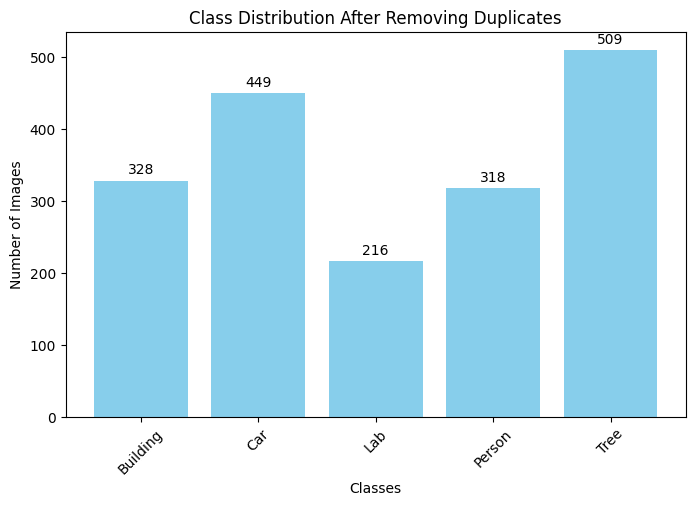

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
bars = plt.bar(class_counts.keys(), class_counts.values(), color='skyblue')
plt.title("Class Distribution After Removing Duplicates")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)

# Show numbers on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, yval, ha='center', va='bottom')

plt.show()


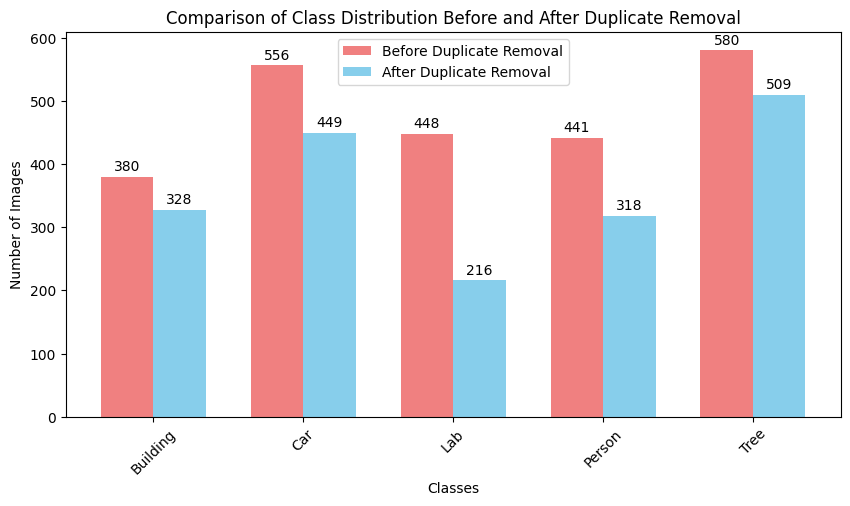

In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np

# ===== Step 1: Define counts BEFORE duplicate removal =====
before_counts = {
    "Building": 380,
    "Car": 556,
    "Lab": 448,
    "Person": 441,
    "Tree": 580,
}



# ===== Step : Count images AFTER duplicate removal =====
clean_dataset = "/content/drive/MyDrive/final_dataset"

after_counts = {}
for cls in os.listdir(clean_dataset):
    cls_path = os.path.join(clean_dataset, cls)
    if os.path.isdir(cls_path):
        after_counts[cls] = len(os.listdir(cls_path))

# ===== Step 3: Prepare bar plot =====
classes = list(before_counts.keys())
before = [before_counts[cls] for cls in classes]
after = [after_counts[cls] for cls in classes]

x = np.arange(len(classes))
width = 0.35

plt.figure(figsize=(10,5))
plt.bar(x - width/2, before, width, label='Before Duplicate Removal', color='lightcoral')
plt.bar(x + width/2, after, width, label='After Duplicate Removal', color='skyblue')

plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.title("Comparison of Class Distribution Before and After Duplicate Removal")
plt.xticks(x, classes, rotation=45)
plt.legend()

# Show counts on top of bars
for i in range(len(classes)):
    plt.text(i - width/2, before[i]+5, before[i], ha='center', va='bottom')
    plt.text(i + width/2, after[i]+5, after[i], ha='center', va='bottom')

plt.show()


In [ ]:
import os
print(os.listdir("/content/drive/MyDrive/final_dataset"))

['Building', 'Car', 'Lab', 'Person', 'Tree']


In [ ]:
import os
import shutil
import random

final_dir = "/content/drive/MyDrive/final_dataset"
split_dir = "/content/drive/MyDrive/dataset_split"

train_ratio = 0.7
val_ratio = 0.15

for cls in os.listdir(final_dir):
    cls_path = os.path.join(final_dir, cls)
    if not os.path.isdir(cls_path):
        continue

    images = os.listdir(cls_path)
    random.shuffle(images)

    train_end = int(train_ratio * len(images))
    val_end = int((train_ratio + val_ratio) * len(images))

    splits = {
        "train": images[:train_end],
        "val": images[train_end:val_end],
        "test": images[val_end:]
    }

    for split, imgs in splits.items():
        out_dir = os.path.join(split_dir, split, cls)
        os.makedirs(out_dir, exist_ok=True)

        for img in imgs:
            shutil.copy(
                os.path.join(cls_path, img),
                os.path.join(out_dir, img)
            )

print("✅ Split completed successfully")

✅ Split completed successfully


In [ ]:
!ls /content/drive/MyDrive/dataset_split


test  train  val


In [ ]:
import os
import numpy as np
from PIL import Image
import uuid
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ===== Train directory =====
train_dir = "/content/drive/MyDrive/dataset_split/train"

# ===== Count images per class =====
class_counts = {
    cls: len(os.listdir(os.path.join(train_dir, cls)))
    for cls in os.listdir(train_dir)
}

print("Before augmentation:", class_counts)

# ===== Target = largest class =====
target_count = max(class_counts.values())
print("Target per class:", target_count)

# ===== Augmentation settings =====
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

# ===== Apply augmentation =====
for cls, count in class_counts.items():
    cls_path = os.path.join(train_dir, cls)
    images = os.listdir(cls_path)

    to_generate = target_count - count
    if to_generate <= 0:
        continue

    print(f"Augmenting {cls}: generating {to_generate} images")

    i = 0
    while i < to_generate:
        img_name = images[i % len(images)]
        img_path = os.path.join(cls_path, img_name)

        img = Image.open(img_path).convert("RGB").resize((224, 224))
        img_array = np.array(img)
        img_array = img_array.reshape((1, *img_array.shape))

        for batch in datagen.flow(img_array, batch_size=1):
            new_name = f"aug_{uuid.uuid4().hex}.jpg"
            Image.fromarray(batch[0].astype("uint8")).save(
                os.path.join(cls_path, new_name)
            )
            break

        i += 1

print("✅ Augmentation completed")

Before augmentation: {'Building': 425, 'Car': 448, 'Lab': 401, 'Person': 424, 'Tree': 470}
Target per class: 470
Augmenting Building: generating 45 images
Augmenting Car: generating 22 images
Augmenting Lab: generating 69 images
Augmenting Person: generating 46 images
✅ Augmentation completed


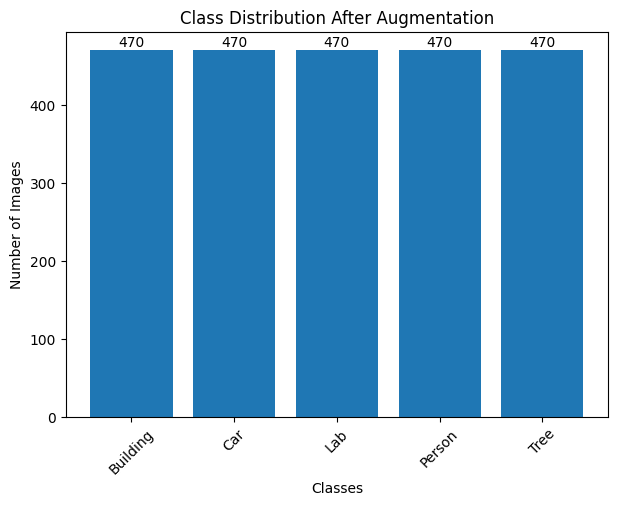

In [ ]:
after_counts = {
    cls: len(os.listdir(os.path.join(train_dir, cls)))
    for cls in os.listdir(train_dir)
}

plt.figure(figsize=(7,5))
plt.bar(after_counts.keys(), after_counts.values())
plt.title("Class Distribution After Augmentation")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)

for cls, count in after_counts.items():
    plt.text(list(after_counts.keys()).index(cls), count + 5, count, ha='center')

plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!ls /content/drive

MyDrive


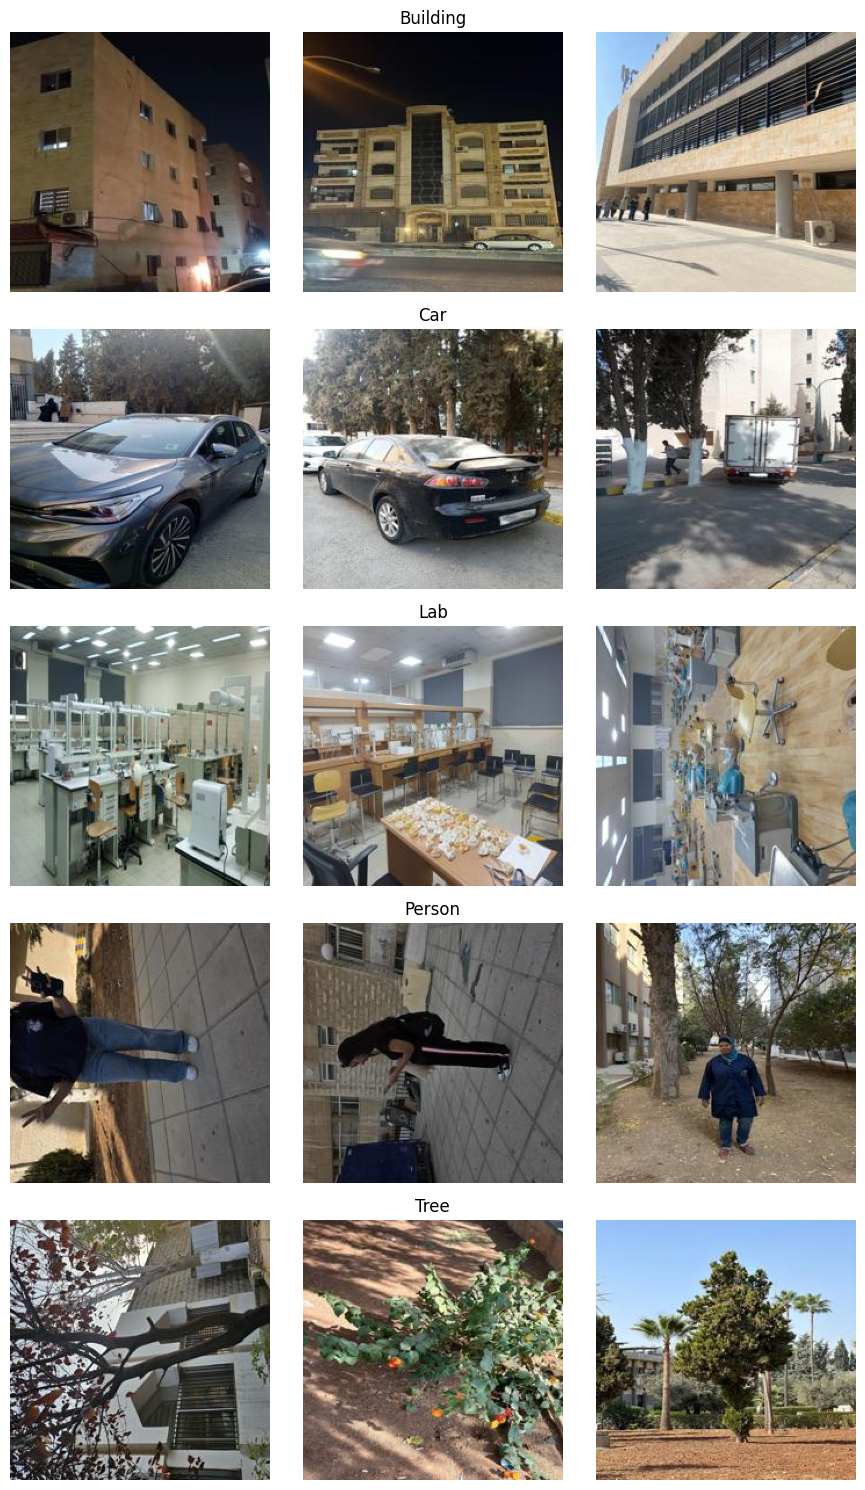

In [ ]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import random

# ===== مسار البيانات =====
dataset_dir = "/content/drive/MyDrive/final_dataset"

# ===== إعداد الرسم =====
classes = os.listdir(dataset_dir)
num_classes = len(classes)
num_samples_per_class = 3  # عدد الصور لكل فئة للعرض

plt.figure(figsize=(num_samples_per_class*3, num_classes*3))

# ===== عرض الصور =====
for i, cls in enumerate(classes):
    cls_path = os.path.join(dataset_dir, cls)
    images = os.listdir(cls_path)

    # اختار عينات عشوائية لكل فئة
    sample_images = random.sample(images, min(num_samples_per_class, len(images)))

    for j, img_name in enumerate(sample_images):
        img_path = os.path.join(cls_path, img_name)
        img = Image.open(img_path)

        plt_idx = i*num_samples_per_class + j + 1
        plt.subplot(num_classes, num_samples_per_class, plt_idx)
        plt.imshow(img)
        plt.axis('off')
        if j == 1:
            plt.title(cls)  # ضع اسم الفئة أعلى العمود الأوسط

plt.tight_layout()
plt.show()


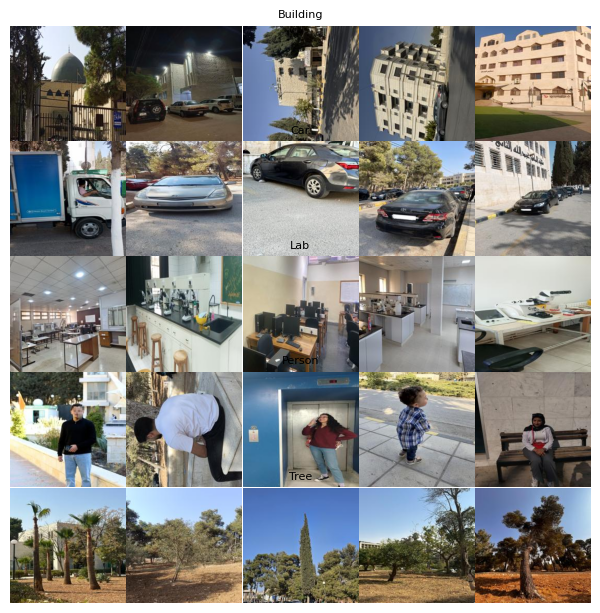

In [ ]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import random

# ===== مسار البيانات =====
dataset_dir = "/content/drive/MyDrive/final_dataset"

# ===== إعداد الرسم =====
classes = os.listdir(dataset_dir)
num_classes = len(classes)
num_samples_per_class = 5  # عدد الصور لكل فئة للعرض

# استخدم subplots مع tight layout بدون فراغات
fig, axes = plt.subplots(num_classes, num_samples_per_class, figsize=(num_samples_per_class*1.5, num_classes*1.5))

for i, cls in enumerate(classes):
    cls_path = os.path.join(dataset_dir, cls)
    images = os.listdir(cls_path)

    sample_images = random.sample(images, min(num_samples_per_class, len(images)))

    for j, img_name in enumerate(sample_images):
        img_path = os.path.join(cls_path, img_name)
        img = Image.open(img_path)
        axes[i, j].imshow(img)
        axes[i, j].axis('off')
        if j == num_samples_per_class // 2:
            axes[i, j].set_title(cls, fontsize=8)  # اسم الفئة فوق الصورة الوسطى

# إزالة أي فراغات بين الصور
plt.subplots_adjust(wspace=0, hspace=0)
plt.show()
